In [1]:
!pip3 install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.m

## Imports

In [7]:
import os
import shutil

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Loading data

In [8]:
stats_df = pd.read_csv('data/9/all_player_stats.csv')
stats_df.head()

,player_id,league,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
0,804508,Premier League,29,23,1907,11,0,9.3498,1.767505,6.572414,43,17,4,0,6,1,0
1,934235,Premier League,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0
2,794839,Premier League,11,2,306,2,0,1.7605,0.203329,6.527273,14,9,2,0,4,2,0
3,922573,Premier League,25,9,852,1,3,3.3793,0.991020,6.616000,25,10,2,0,10,0,0
4,836705,Premier League,6,3,264,0,1,0.3077,0.097873,6.650000,5,1,0,0,3,0,0


## Mini EDA

In [9]:
stats_df.info()
stats_df.isna().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 3675 entries, 0 to 3674
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3675 non-null   int64  
 1   league            3675 non-null   str    
 2   appearances       3675 non-null   int64  
 3   matches_started   3675 non-null   int64  
 4   minutes_played    3675 non-null   int64  
 5   goals             3675 non-null   int64  
 6   assists           3675 non-null   int64  
 7   expected_goals    3134 non-null   float64
 8   expected_assists  3655 non-null   float64
 9   rating            3675 non-null   float64
 10  total_shots       3675 non-null   int64  
 11  shots_on_target   3675 non-null   int64  
 12  yellow_cards      3675 non-null   int64  
 13  red_cards         3675 non-null   int64  
 14  tackles           3675 non-null   int64  
 15  interceptions     3675 non-null   int64  
 16  saves             3675 non-null   int64  
dtypes: flo

expected_goals      541
expected_assists     20
player_id             0
league                0
appearances           0
minutes_played        0
matches_started       0
assists               0
goals                 0
rating                0
total_shots           0
shots_on_target       0
yellow_cards          0
red_cards             0
tackles               0
interceptions         0
saves                 0
dtype: int64

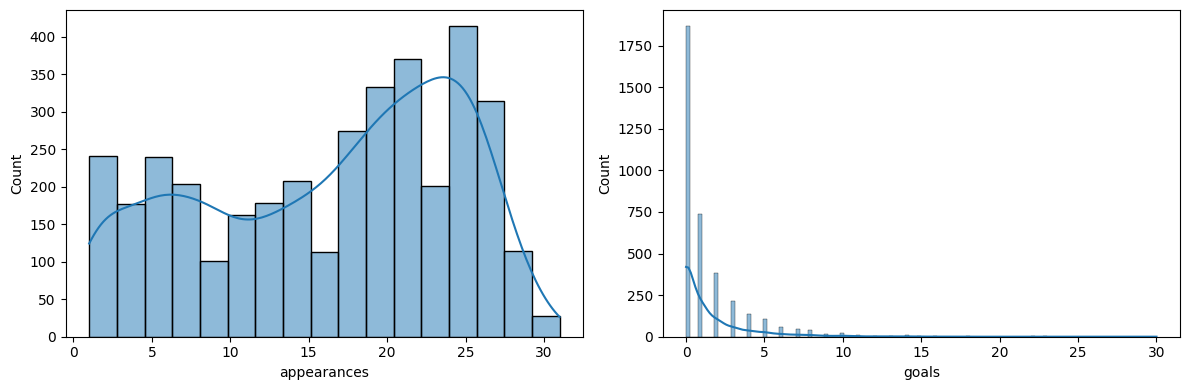

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(stats_df['appearances'].dropna(), kde=True, ax=axes[0])
sns.histplot(stats_df['goals'].dropna(), kde=True, ax=axes[1])
plt.tight_layout()

## Feature proecessing

In [14]:
feature_columns = ['appearances', 'matches_started', 'minutes_played',
                   'goals', 'assists', 'expected_goals', 'expected_assists',
                   'rating', 'total_shots', 'shots_on_target', 'yellow_cards',
                   'red_cards', 'tackles', 'interceptions', 'saves']
X = stats_df[feature_columns].copy()

processed = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_preprocessed = processed.fit_transform(X)
X_preprocessed.shape

(3675, 15)